In [1]:
from pathlib import Path
from itertools import combinations
from datetime import datetime
import shutil
import json
import pandas as pd

from viberank.comparators.dummy import DummyComparator
from viberank.utils.logging import JSONLResponseLogger

In [2]:
# VISPDAT-only paths
raw_root = Path("../data/raw/hmls")
dataset_name = "VISPDAT"

prompt_path = raw_root / "prompt.txt"
raw_dataset_dir = raw_root / dataset_name
responses_dir = raw_dataset_dir / "responses"

selected_csv = Path("../data/processed/pairwise_comparisons/hmls") / dataset_name / "selected_households.csv"

# temporary flat folder just for the selected JSONs
flat_json_dir = responses_dir / "_selected_jsons"

responses_dir.mkdir(parents=True, exist_ok=True)
flat_json_dir.mkdir(parents=True, exist_ok=True)

print("prompt_path:", prompt_path)
print("raw_dataset_dir:", raw_dataset_dir)
print("responses_dir:", responses_dir)
print("selected_csv:", selected_csv)
print("flat_json_dir:", flat_json_dir)

prompt_path: ../data/raw/hmls/prompt.txt
raw_dataset_dir: ../data/raw/hmls/VISPDAT
responses_dir: ../data/raw/hmls/VISPDAT/responses
selected_csv: ../data/processed/pairwise_comparisons/hmls/VISPDAT/selected_households.csv
flat_json_dir: ../data/raw/hmls/VISPDAT/responses/_selected_jsons


In [3]:
selected = pd.read_csv(selected_csv)

selected["Client Uid"] = pd.to_numeric(selected["Client Uid"], errors="coerce").astype("Int64")
selected["GRAND TOTAL"] = pd.to_numeric(selected["GRAND TOTAL"], errors="coerce")

selected = selected.dropna(subset=["Client Uid", "priority_band", "GRAND TOTAL"]).copy()
selected["Client Uid"] = selected["Client Uid"].astype("Int64")
selected["priority_band"] = selected["priority_band"].astype(str).str.lower()

selected = selected.sort_values(
    by=["priority_band", "within_band_position", "GRAND TOTAL", "Client Uid"]
).reset_index(drop=True)

print("num selected households:", len(selected))
print("uids:", selected["Client Uid"].astype(str).tolist())
print(selected[["priority_band", "within_band_position", "Client Uid", "GRAND TOTAL"]])

num selected households: 9
uids: ['588', '263962', '234634', '51360', '342209', '352916', '505', '333094', '349157']
  priority_band within_band_position  Client Uid  GRAND TOTAL
0          high                lower         588            8
1          high               middle      263962            9
2          high                upper      234634           15
3           low                lower       51360            1
4           low               middle      342209            2
5           low                upper      352916            3
6        medium                lower         505            4
7        medium               middle      333094            5
8        medium                upper      349157            7


In [4]:
# clear out any old temp files first
for p in flat_json_dir.glob("*.json"):
    p.unlink()

missing = []

for _, row in selected.iterrows():
    uid = str(int(row["Client Uid"]))
    band = row["priority_band"]

    src = raw_dataset_dir / band / f"{uid}.json"
    dst = flat_json_dir / f"{uid}.json"

    if not src.exists():
        missing.append(src)
        continue

    shutil.copy2(src, dst)

if missing:
    print("Missing files:")
    for p in missing:
        print("  ", p)
else:
    print("All selected VISPDAT JSONs copied successfully.")

copied = sorted([p.name for p in flat_json_dir.glob("*.json")])
print("num copied jsons:", len(copied))
print(copied)

All selected VISPDAT JSONs copied successfully.
num copied jsons: 9
['234634.json', '263962.json', '333094.json', '342209.json', '349157.json', '352916.json', '505.json', '51360.json', '588.json']


In [5]:
items = [str(int(x)) for x in selected["Client Uid"].tolist()]

tie_sheet = [
    (a, b)
    for a in items
    for b in items
    if a != b
]

print("num items:", len(items))
print("num pairs:", len(tie_sheet))
print("first 5 pairs:", tie_sheet[:5])

num items: 9
num pairs: 72
first 5 pairs: [('588', '263962'), ('588', '234634'), ('588', '51360'), ('588', '342209'), ('588', '352916')]


In [6]:
run_id = datetime.now().strftime("dummy_vispdat_%Y%m%d_%H%M%S")
log_path = responses_dir / f"{run_id}.jsonl"

logger = JSONLResponseLogger(
    log_path=log_path,
    flush_every=1,
    store_prompts=True,
)

logger.log_run_start(
    run_id=run_id,
    dataset_name=dataset_name,
    model_name="dummy",
    prompt_version="prompt.txt",
    extra={
        "num_items": len(items),
        "num_pairs": len(tie_sheet),
        "num_samples": 100,
    },
)

print("log file:", log_path)

log file: ../data/raw/hmls/VISPDAT/responses/dummy_vispdat_20260402_003527.jsonl


In [7]:
comp = DummyComparator(
    items=items,
    num_samples=100,              
    results_folder=responses_dir,
    data_folder=flat_json_dir,
    prompt_path=prompt_path,
    logger=logger,
    rng_seed=42,
)

win_matrix = comp.compare_items(tie_sheet)

logger.log_run_end(
    run_id=run_id,
    extra={
        "num_comparisons_recorded": int(comp.num_comparisons),
    },
)

logger.close()

print("Finished.")
print("win_matrix shape:", win_matrix.shape)
print("num_comparisons:", comp.num_comparisons)

Finished.
win_matrix shape: (9, 9)
num_comparisons: 7200


In [8]:
with open(log_path, "r", encoding="utf-8") as f:
    records = [json.loads(line) for line in f]

print("num log records:", len(records))
print("event counts:")
print(pd.Series([r["event"] for r in records]).value_counts())

num log records: 7274
event counts:
response     7200
pair_view      72
run_start       1
run_end         1
Name: count, dtype: int64


In [9]:
for r in records[:5]:
    print(json.dumps(r, indent=2)[:1200])
    print("-" * 80)

{
  "event": "run_start",
  "timestamp": "2026-04-02T04:35:27.176358+00:00",
  "run_id": "dummy_vispdat_20260402_003527",
  "dataset_name": "VISPDAT",
  "model_name": "dummy",
  "prompt_version": "prompt.txt",
  "extra": {
    "num_items": 9,
    "num_pairs": 72,
    "num_samples": 100
  }
}
--------------------------------------------------------------------------------
{
  "event": "pair_view",
  "timestamp": "2026-04-02T04:35:27.181987+00:00",
  "pair_key": "588__263962",
  "pair_direction": [
    "588",
    "263962"
  ],
  "order": "as_given",
  "left_item": "588",
  "right_item": "263962",
  "prompt_hash": "c06a907b5dae53218da251f45691c4770b208c55b25653d1e10dfc0a2cbda4b4",
  "prompt": "<|begin_of_text|>\n<|start_header_id|>system<|end_header_id|>\nCommunities across the US provide homeless services that respond to household requests for assistance in securing stable housing. Households call a hotline to request help and provide basic demographic details such as household size, mon

In [10]:
# only run this if you want to remove the copied temp JSONs
for p in flat_json_dir.glob("*.json"):
    p.unlink()

print("Temporary flat JSONs removed.")

Temporary flat JSONs removed.


In [ ]:
from viberank.utils.plotting.pairwise_hmls import make_heatmap_for_run

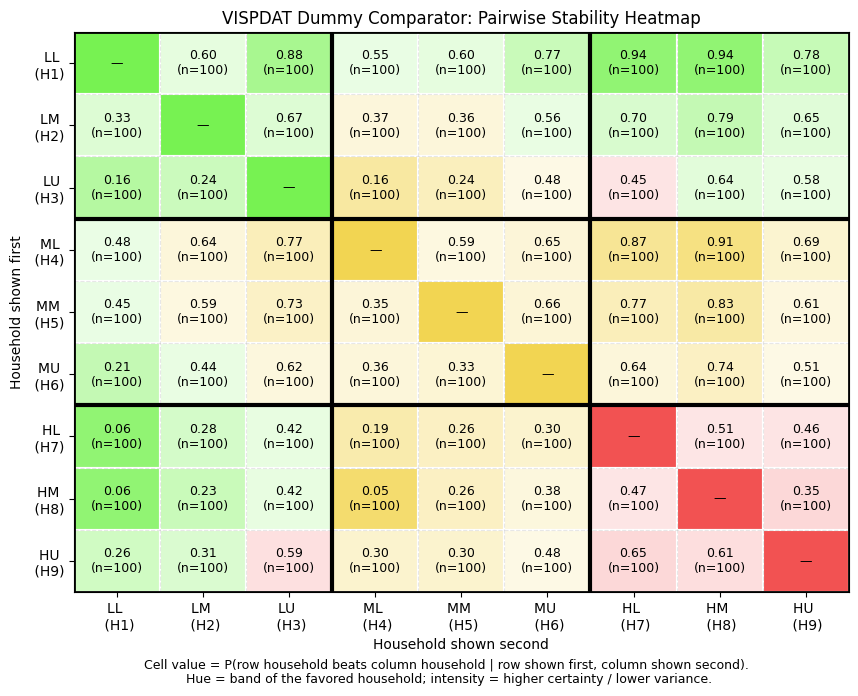

In [24]:
dataset_name = "VISPDAT"

selected_csv = Path("../data/processed/pairwise_comparisons/hmls") / dataset_name / "selected_households.csv"
log_path = Path("../data/raw/hmls") / dataset_name / "responses" / "dummy_vispdat_20260402_003259.jsonl"




selected_df, trials_df, prob_matrix, n_matrix = make_heatmap_for_run(
    selected_csv=selected_csv,
    log_path=log_path,
    title="VISPDAT Dummy Comparator: Pairwise Stability Heatmap",
    save_path=Path("../data/raw/hmls") / "VISPDAT" / "responses" / "vispdat_dummy_heatmap.png",
)